In [57]:
import numpy as np
import pandas as pd
from copy import deepcopy
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

def calc_feature(vals, lag, agg, window, i):
    if i - lag - window + 1 < 0:
        return None
    if agg == 'sum':
        ans = sum(vals[i - lag - window + 1:i - lag + 1])
    elif agg == 'mean':
        ans = sum(vals[i - lag - window + 1:i - lag + 1]) / window
    elif agg.startswith('percentile_'):
        prc = int(agg.split('_')[1])
        ans = np.percentile(np.array(vals[i - lag - window + 1:i - lag + 1]), prc)
    else:
        ans = None
    return ans

def lagged_features(data, date_col, cols, lags, agg_methods, windows):
    data = data.sort_values(date_col)
    res = deepcopy(data)

    for col in cols:
        for lag in lags:
            for agg in agg_methods:
                for window in windows:
                    values = []
                    for i in range(len(res)):
                        values.append(calc_feature(res[col].to_list(), lag, agg, window, i))
                    res[f'{col}_lag_{lag}_agg_{agg}_window_{window}'] = values
    
    return res.reset_index()


df = pd.read_pickle('electronika_clean.pkl')
df

,Order_ID,Email_new,Phone_new,Source,OrderDate,время,месяц,ChangeDate,DeliveryDate,PaymentDate,...,Quant,RowPrice,RowDiscount,RowSum,Brand,TN,TK,NomFullPath,Week,Nom_ID
2,1303000509_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,08:46:30.000,201603,2016-03-30 09:31:57.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,1.0,35999.0,0.0,35999.0,Samsung,ТВ-Аудио,Телевизоры LCD,"Телевизоры, аудио, видео/Телевизоры/Smart теле...",13.0,95567.0
4,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,3990.0,0.0,7980.0,NaN,NaN,NaN,Установка и настройка техники/Установка и наст...,13.0,2748.0
5,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,4490.0,0.0,8980.0,NaN,NaN,NaN,Установка и настройка техники/Установка и наст...,13.0,7874.0
7,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,32999.0,0.0,65998.0,Sony,ТВ-Аудио,Телевизоры LCD,"Телевизоры, аудио, видео/Телевизоры/Smart теле...",13.0,99485.0
8,1303000510_TT,55666668105117_iu29@yandex.ru,55485656-57565656575275,Онлайн-Резерв.,2016-03-30,11:22:51.000,201603,2016-03-30 11:24:32.000,2016-04-06 00:00:00.000,1900-01-01 00:00:00.000,...,2.0,999.0,0.0,1998.0,РЭМО,Аксессуары,Аксессуары ТВ-Аудио,"Телевизоры, аудио, видео/Аксессуары для ТВ/Ант...",13.0,20709.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
357019,5898089_BX,6666449117_1u9@bk.ru,55574957-51495048515075,Онлайн-Резерв.,2016-04-30,23:51:37.000,201604,2016-05-03 12:55:07.000,2016-05-02 00:00:00.000,2016-05-02 00:10:22.000,...,1.0,899.0,0.0,899.0,Saturn,Климат,Вентиляторы бытовые,Техника для дома/Климатическая техника/Кондици...,17.0,38755.0
357021,5898095_BX,666661118109_vm27@yahoo.com,55575452-55554849505278,Онлайн-Резерв.,2016-04-30,23:54:03.000,201604,2016-05-04 19:43:40.000,2016-05-07 00:00:00.000,2016-05-04 19:43:41.000,...,1.0,1090.0,0.0,1090.0,Case Logic,Аксессуары,Аксессуары для фото/видео,Фото- и видеотехника/Аксессуары для фото и вид...,17.0,31908.0
357023,5898099_BX,3110116_nt16@pisem.net,55574948-50554849554878,Онлайн-Резерв.,2016-04-30,23:56:02.000,201604,2016-05-01 11:57:42.000,2016-05-08 00:00:00.000,1900-01-01 00:00:00.000,...,1.0,6859.0,0.0,6859.0,ELIKOR,Крупная бытовая техника,Встраиваемая техника,Встраиваемая техника/Вытяжки/,17.0,140459.0
357024,5898102_BX,55666665102117_fu13@list.ru,55575648-51484956545071,Онлайн-Резерв.,2016-04-30,23:56:38.000,201604,2016-05-06 20:18:49.000,2016-05-05 00:00:00.000,2016-05-06 20:18:50.000,...,1.0,9120.0,0.0,9120.0,FORWARD,Спорт и активный отдых,Велосипеды и аксессуары,Товары для спорта и отдыха/Велосипеды и аксесс...,17.0,295956.0


# Без учета внешних факторов

## Крупная бытовая техника

In [59]:
category_name = 'Крупная бытовая техника'

daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1
daily_sales.head(10)

,Quant,weekday,monthday,is_weekend
OrderDate,,,,
2016-03-01,477.0,1,1,0
2016-03-02,460.0,2,2,0
2016-03-03,434.0,3,3,0
2016-03-04,427.0,4,4,0
2016-03-05,735.0,5,5,1
2016-03-06,682.0,6,6,1
2016-03-07,631.0,0,7,0
2016-03-08,496.0,1,8,0
2016-03-09,404.0,2,9,0


In [60]:
params = [
    {
        'cols': ['Quant'],
        'lags': [14, 20],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3, 7]
    }
]

for i, param in enumerate(params):
    print(f'Param set: {i}')
    
    data_features = lagged_features(daily_sales, 'OrderDate', param['cols'], param['lags'], param['agg'], param['windows'])

    train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
    train_df.fillna(-1000, inplace=True)
    test_df.fillna(-1000, inplace=True)
    X = train_df.drop(['Quant', 'OrderDate'], axis=1)
    y = train_df.Quant

    X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
    y_test = test_df.Quant

    categorical_features_indices = np.where(X.dtypes != float)[0]

    model = CatBoostRegressor(
        loss_function='MAPE',
        random_seed=42,
        logging_level='Silent'
    )

    model.fit(
        X, y,
        eval_set=(X_test, y_test),
        cat_features=categorical_features_indices,
        use_best_model=True,
        plot=True
    )

Param set: 0


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 1


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 2


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [61]:
data_features = lagged_features(daily_sales, 'OrderDate', params[2]['cols'], params[2]['lags'], params[2]['agg'], params[2]['windows'])

train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    eval_set=(X_test, y_test),
    cat_features=categorical_features_indices,
    use_best_model=True
)

X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3040928374.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3040928374.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


,Quant,weekday,monthday,is_weekend,Predictions
OrderDate,,,,,
2016-03-01,477.0,1,1,0,-1.000000
2016-03-02,460.0,2,2,0,-1.000000
2016-03-03,434.0,3,3,0,-1.000000
2016-03-04,427.0,4,4,0,-1.000000
2016-03-05,735.0,5,5,1,-1.000000
...,...,...,...,...,...
2016-04-26,530.0,1,26,0,425.464698
2016-04-27,478.0,2,27,0,423.446500
2016-04-28,409.0,3,28,0,429.529442


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/1067484517.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


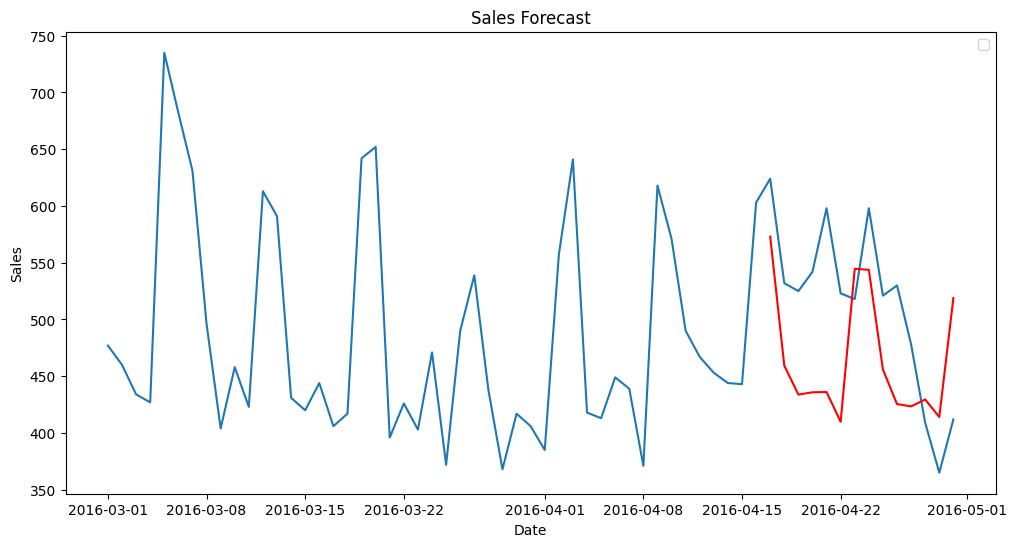

MAE: 76.97214012873133
MSE: 7323.270385159643
MAPE: 14.98190861331993


In [62]:
# Forecast future values
forecast_periods = 14  # Forecast the next 12 months
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

## Сделай Сам

In [64]:
category_name = 'Сделай сам'

daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1
daily_sales.head(10)

,Quant,weekday,monthday,is_weekend
OrderDate,,,,
2016-03-01,249.0,1,1,0
2016-03-02,247.0,2,2,0
2016-03-03,269.0,3,3,0
2016-03-04,290.0,4,4,0
2016-03-05,229.0,5,5,1
2016-03-06,208.0,6,6,1
2016-03-07,245.0,0,7,0
2016-03-08,197.0,1,8,0
2016-03-09,314.0,2,9,0


In [65]:
params = [
    {
        'cols': ['Quant'],
        'lags': [14, 20],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3, 7]
    }
]

for i, param in enumerate(params):
    print(f'Param set: {i}')
    
    data_features = lagged_features(daily_sales, 'OrderDate', param['cols'], param['lags'], param['agg'], param['windows'])

    train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
    train_df.fillna(-1000, inplace=True)
    test_df.fillna(-1000, inplace=True)
    X = train_df.drop(['Quant', 'OrderDate'], axis=1)
    y = train_df.Quant

    X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
    y_test = test_df.Quant

    categorical_features_indices = np.where(X.dtypes != float)[0]

    model = CatBoostRegressor(
        loss_function='MAPE',
        random_seed=42,
        logging_level='Silent'
    )

    model.fit(
        X, y,
        eval_set=(X_test, y_test),
        cat_features=categorical_features_indices,
        use_best_model=True,
        plot=True
    )

Param set: 0


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 1


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 2


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [66]:
data_features = lagged_features(daily_sales, 'OrderDate', params[0]['cols'], params[0]['lags'], params[0]['agg'], params[0]['windows'])

train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    eval_set=(X_test, y_test),
    cat_features=categorical_features_indices,
    use_best_model=True
)

X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/892333169.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/892333169.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


,Quant,weekday,monthday,is_weekend,Predictions
OrderDate,,,,,
2016-03-01,249.0,1,1,0,-1.000000
2016-03-02,247.0,2,2,0,-1.000000
2016-03-03,269.0,3,3,0,-1.000000
2016-03-04,290.0,4,4,0,-1.000000
2016-03-05,229.0,5,5,1,-1.000000
...,...,...,...,...,...
2016-04-26,533.0,1,26,0,278.338709
2016-04-27,387.0,2,27,0,298.284171
2016-04-28,400.0,3,28,0,286.901767


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


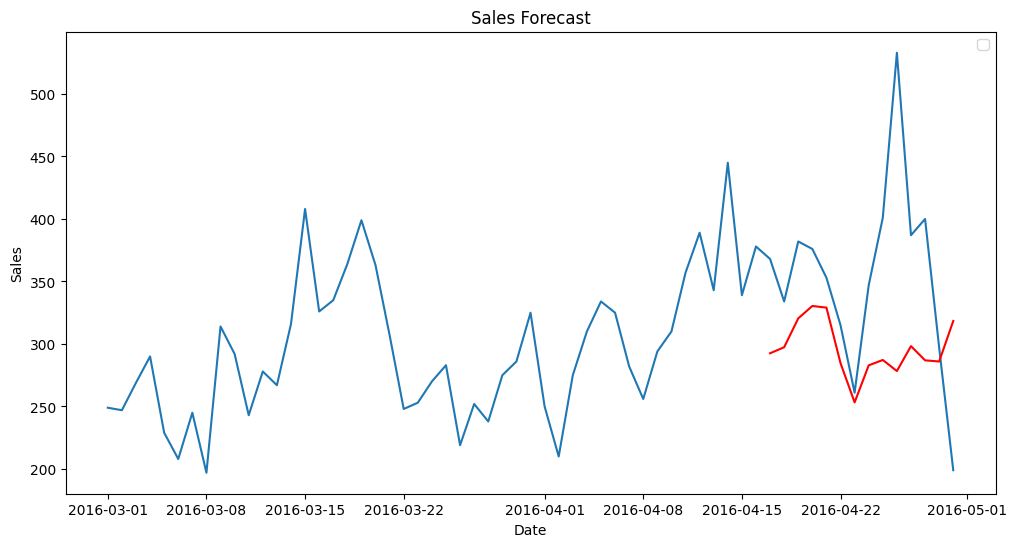

MAE: 74.70767303766696
MSE: 9385.161591987158
MAPE: 20.61312674446396


In [67]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

# С учетом акций

In [70]:
actions_values = df['Actions'].value_counts().index
actions_set = set()
for action in actions_values:
    values = action.split(',')
    for value in values:
        actions_set.add(value)

for col in list(actions_set):
    df[col] = df['Actions'].apply(lambda x: int(str(x).find(col) != -1))
df['Quant_action'] = df['Quant'] * df['СкидкаСуммойПроцентомСЛимитом']

## Крупная бытовая техника

In [71]:
category_name = 'Крупная бытовая техника'

daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,
2016-03-01,477.0,1,1,0,1
2016-03-02,460.0,2,2,0,1
2016-03-03,434.0,3,3,0,1
2016-03-04,427.0,4,4,0,1
2016-03-05,735.0,5,5,1,1
2016-03-06,682.0,6,6,1,1
2016-03-07,631.0,0,7,0,1
2016-03-08,496.0,1,8,0,1
2016-03-09,404.0,2,9,0,1


In [72]:
params = [
    {
        'cols': ['Quant'],
        'lags': [14, 20],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3, 7]
    }
]

for i, param in enumerate(params):
    print(f'Param set: {i}')
    
    data_features = lagged_features(daily_sales, 'OrderDate', param['cols'], param['lags'], param['agg'], param['windows'])

    train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
    train_df.fillna(-1000, inplace=True)
    test_df.fillna(-1000, inplace=True)
    X = train_df.drop(['Quant', 'OrderDate'], axis=1)
    y = train_df.Quant

    X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
    y_test = test_df.Quant

    categorical_features_indices = np.where(X.dtypes != float)[0]

    model = CatBoostRegressor(
        loss_function='MAPE',
        random_seed=42,
        logging_level='Silent'
    )

    model.fit(
        X, y,
        eval_set=(X_test, y_test),
        cat_features=categorical_features_indices,
        use_best_model=True,
        plot=True
    )

Param set: 0


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 1


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 2


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [73]:
data_features = lagged_features(daily_sales, 'OrderDate', params[2]['cols'], params[2]['lags'], params[2]['agg'], params[2]['windows'])

train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    eval_set=(X_test, y_test),
    cat_features=categorical_features_indices,
    use_best_model=True
)

X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3040928374.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3040928374.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


,Quant,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,
2016-03-01,477.0,1,1,0,1,-1.000000
2016-03-02,460.0,2,2,0,1,-1.000000
2016-03-03,434.0,3,3,0,1,-1.000000
2016-03-04,427.0,4,4,0,1,-1.000000
2016-03-05,735.0,5,5,1,1,-1.000000
...,...,...,...,...,...,...
2016-04-26,530.0,1,26,0,0,433.408292
2016-04-27,478.0,2,27,0,0,428.058511
2016-04-28,409.0,3,28,0,0,429.690194


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


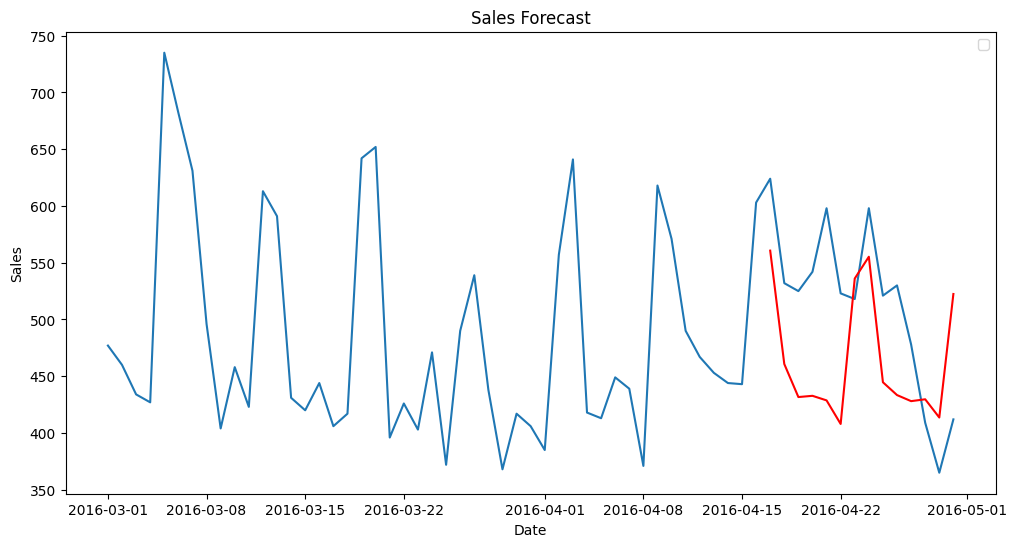

MAE: 77.49265586353447
MSE: 7601.129032034404
MAPE: 15.066032163107806


In [74]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

## Сделай Сам

In [75]:
category_name = 'Сделай сам'

daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'Quant']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,
2016-03-01,249.0,1,1,0,0
2016-03-02,247.0,2,2,0,0
2016-03-03,269.0,3,3,0,0
2016-03-04,290.0,4,4,0,1
2016-03-05,229.0,5,5,1,1
2016-03-06,208.0,6,6,1,1
2016-03-07,245.0,0,7,0,1
2016-03-08,197.0,1,8,0,1
2016-03-09,314.0,2,9,0,0


In [76]:
params = [
    {
        'cols': ['Quant'],
        'lags': [14, 20],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3, 7]
    }
]

for i, param in enumerate(params):
    print(f'Param set: {i}')
    
    data_features = lagged_features(daily_sales, 'OrderDate', param['cols'], param['lags'], param['agg'], param['windows'])

    train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
    train_df.fillna(-1000, inplace=True)
    test_df.fillna(-1000, inplace=True)
    X = train_df.drop(['Quant', 'OrderDate'], axis=1)
    y = train_df.Quant

    X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
    y_test = test_df.Quant

    categorical_features_indices = np.where(X.dtypes != float)[0]

    model = CatBoostRegressor(
        loss_function='MAPE',
        random_seed=42,
        logging_level='Silent'
    )

    model.fit(
        X, y,
        eval_set=(X_test, y_test),
        cat_features=categorical_features_indices,
        use_best_model=True,
        plot=True
    )

Param set: 0


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 1


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 2


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3494212818.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [77]:
data_features = lagged_features(daily_sales, 'OrderDate', params[0]['cols'], params[0]['lags'], params[0]['agg'], params[0]['windows'])

train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    eval_set=(X_test, y_test),
    cat_features=categorical_features_indices,
    use_best_model=True
)

X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/892333169.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/892333169.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


,Quant,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,
2016-03-01,249.0,1,1,0,0,-1.000000
2016-03-02,247.0,2,2,0,0,-1.000000
2016-03-03,269.0,3,3,0,0,-1.000000
2016-03-04,290.0,4,4,0,1,-1.000000
2016-03-05,229.0,5,5,1,1,-1.000000
...,...,...,...,...,...,...
2016-04-26,533.0,1,26,0,1,304.859570
2016-04-27,387.0,2,27,0,1,310.111397
2016-04-28,400.0,3,28,0,1,301.700386


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


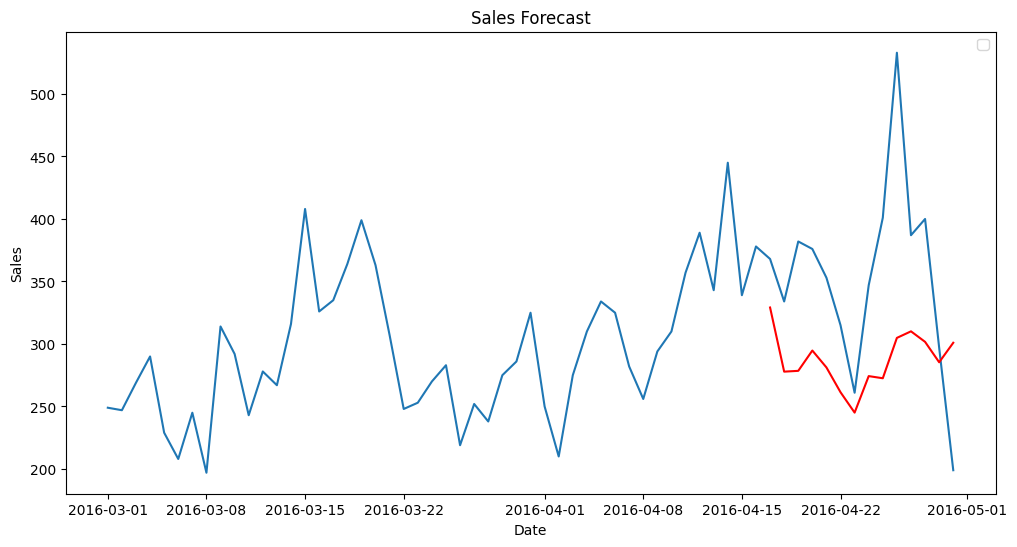

MAE: 81.36289325484053
MSE: 9298.9627083839
MAPE: 22.49251795105524


In [78]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

# С учетом средней цены проданных товаров

## Крупная бытовая техника

In [85]:
category_name = 'Крупная бытовая техника'

daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'Quant', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,477.0,20634.046122,1,1,0,1
2016-03-02,460.0,17987.978261,2,2,0,1
2016-03-03,434.0,18958.693548,3,3,0,1
2016-03-04,427.0,19199.435597,4,4,0,1
2016-03-05,735.0,19090.391837,5,5,1,1
2016-03-06,682.0,20609.206745,6,6,1,1
2016-03-07,631.0,18430.977813,0,7,0,1
2016-03-08,496.0,18752.548387,1,8,0,1
2016-03-09,404.0,18569.400990,2,9,0,1


In [86]:
params = [
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 20],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3, 7]
    }
]

for i, param in enumerate(params):
    print(f'Param set: {i}')
    
    data_features = lagged_features(daily_sales, 'OrderDate', param['cols'], param['lags'], param['agg'], param['windows'])

    train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
    train_df.fillna(-1000, inplace=True)
    test_df.fillna(-1000, inplace=True)
    X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
    y = train_df.Quant

    X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
    y_test = test_df.Quant

    categorical_features_indices = np.where(X.dtypes != float)[0]

    model = CatBoostRegressor(
        loss_function='MAPE',
        random_seed=42,
        logging_level='Silent'
    )

    model.fit(
        X, y,
        eval_set=(X_test, y_test),
        cat_features=categorical_features_indices,
        use_best_model=True,
        plot=True
    )

Param set: 0


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 1


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 2


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [88]:
data_features = lagged_features(daily_sales, 'OrderDate', params[1]['cols'], params[1]['lags'], params[1]['agg'], params[1]['windows'])

train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y = train_df.Quant

X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    eval_set=(X_test, y_test),
    cat_features=categorical_features_indices,
    use_best_model=True,
    plot=True
)

X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3605975558.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3605975558.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,,
2016-03-01,477.0,20634.046122,1,1,0,1,-1.000000
2016-03-02,460.0,17987.978261,2,2,0,1,-1.000000
2016-03-03,434.0,18958.693548,3,3,0,1,-1.000000
2016-03-04,427.0,19199.435597,4,4,0,1,-1.000000
2016-03-05,735.0,19090.391837,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,530.0,19095.318868,1,26,0,0,442.102963
2016-04-27,478.0,18774.543933,2,27,0,0,452.012881
2016-04-28,409.0,18769.254279,3,28,0,0,432.162383


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


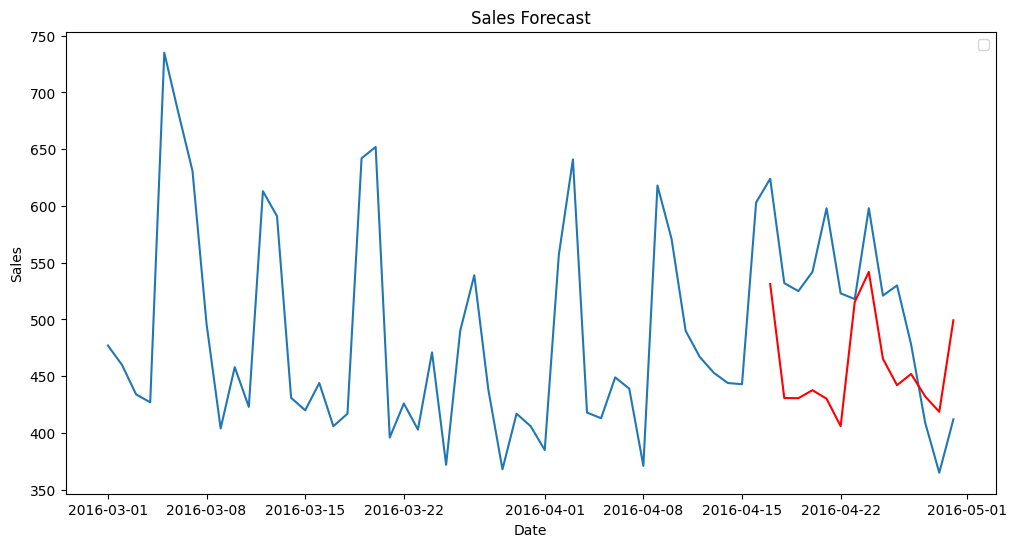

MAE: 76.40696891977905
MSE: 7582.394660625301
MAPE: 14.689919638056779


In [89]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

## Сделай Сам

In [90]:
category_name = 'Сделай сам'

daily_sales = df[df['TN'] == f'{category_name}'][['OrderDate', 'Quant', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,249.0,6595.947791,1,1,0,0
2016-03-02,247.0,5895.591093,2,2,0,0
2016-03-03,269.0,7017.888476,3,3,0,0
2016-03-04,290.0,5388.437931,4,4,0,1
2016-03-05,229.0,5349.694323,5,5,1,1
2016-03-06,208.0,5940.701923,6,6,1,1
2016-03-07,245.0,5423.787755,0,7,0,1
2016-03-08,197.0,5184.142132,1,8,0,1
2016-03-09,314.0,5105.990446,2,9,0,0


In [91]:
params = [
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 20],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3, 7]
    }
]

for i, param in enumerate(params):
    print(f'Param set: {i}')
    
    data_features = lagged_features(daily_sales, 'OrderDate', param['cols'], param['lags'], param['agg'], param['windows'])

    train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
    train_df.fillna(-1000, inplace=True)
    test_df.fillna(-1000, inplace=True)
    X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
    y = train_df.Quant

    X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
    y_test = test_df.Quant

    categorical_features_indices = np.where(X.dtypes != float)[0]

    model = CatBoostRegressor(
        loss_function='MAPE',
        random_seed=42,
        logging_level='Silent'
    )

    model.fit(
        X, y,
        eval_set=(X_test, y_test),
        cat_features=categorical_features_indices,
        use_best_model=True,
        plot=True
    )

Param set: 0


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 1


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 2


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [92]:
data_features = lagged_features(daily_sales, 'OrderDate', params[2]['cols'], params[2]['lags'], params[2]['agg'], params[2]['windows'])

train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'OrderDate'], axis=1)
y = train_df.Quant

X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    eval_set=(X_test, y_test),
    cat_features=categorical_features_indices,
    use_best_model=True
)

X_test = test_df.drop(['Quant', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3040928374.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3040928374.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,,
2016-03-01,249.0,6595.947791,1,1,0,0,-1.000000
2016-03-02,247.0,5895.591093,2,2,0,0,-1.000000
2016-03-03,269.0,7017.888476,3,3,0,0,-1.000000
2016-03-04,290.0,5388.437931,4,4,0,1,-1.000000
2016-03-05,229.0,5349.694323,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,533.0,6360.566604,1,26,0,1,308.824904
2016-04-27,387.0,7421.994832,2,27,0,1,314.045422
2016-04-28,400.0,6990.357500,3,28,0,1,298.938845


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


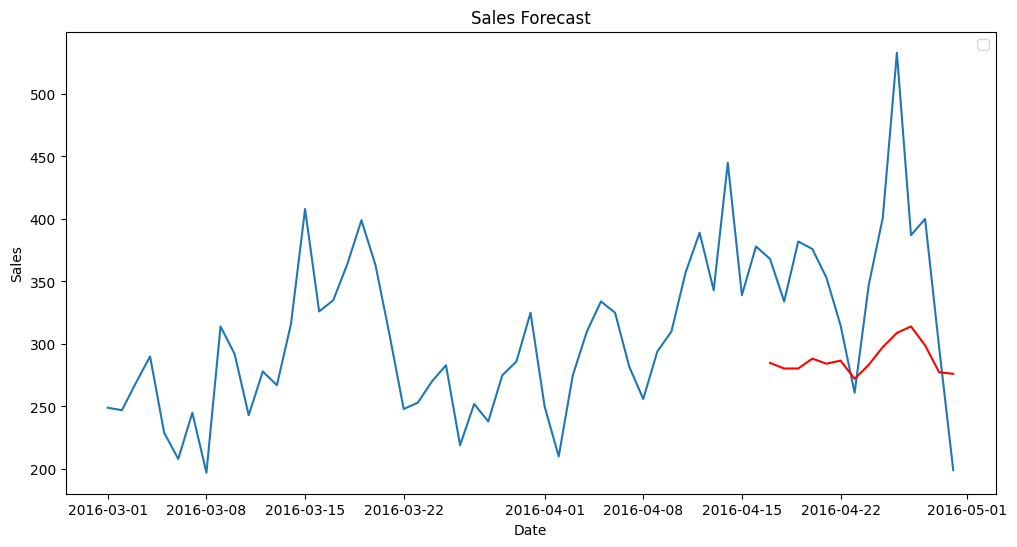

MAE: 78.32053356257428
MSE: 8596.711081998395
MAPE: 21.216912578451392


In [93]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

# С учетом кластеризации

In [94]:
clustering_results_1 = pd.read_csv('clustering_results_1.csv')
df_clustering_1 = df.join(clustering_results_1[['Phone_new', 'cluster']].set_index('Phone_new'), on='Phone_new')
df_clustering_1['cluster'].value_counts()

cluster
1     107337
8      49173
0      18523
6       6630
2       1500
9       1433
5       1356
12      1248
10       355
13       175
11        11
3          8
4          2
7          1
Name: count, dtype: int64

## Крупная бытовая техника

### Кластер 1

In [95]:
category_name = 'Крупная бытовая техника'
cluster = 1

daily_sales = df_clustering_1[(df_clustering_1['cluster'] == cluster) & (df_clustering_1['TN'] == f'{category_name}')][['OrderDate', 'Quant', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,244.0,17896.356557,1,1,0,1
2016-03-02,269.0,16862.360595,2,2,0,1
2016-03-03,223.0,17375.071749,3,3,0,1
2016-03-04,218.0,17723.449541,4,4,0,1
2016-03-05,417.0,16992.827338,5,5,1,1
2016-03-06,376.0,19114.106383,6,6,1,1
2016-03-07,318.0,16288.949686,0,7,0,1
2016-03-08,273.0,17409.838828,1,8,0,1
2016-03-09,212.0,16141.080189,2,9,0,1


In [96]:
params = [
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 20],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3, 7]
    }
]

for i, param in enumerate(params):
    print(f'Param set: {i}')
    
    data_features = lagged_features(daily_sales, 'OrderDate', param['cols'], param['lags'], param['agg'], param['windows'])

    train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
    train_df.fillna(-1000, inplace=True)
    test_df.fillna(-1000, inplace=True)
    X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
    y = train_df.Quant

    X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
    y_test = test_df.Quant

    categorical_features_indices = np.where(X.dtypes != float)[0]

    model = CatBoostRegressor(
        loss_function='MAPE',
        random_seed=42,
        logging_level='Silent'
    )

    model.fit(
        X, y,
        eval_set=(X_test, y_test),
        cat_features=categorical_features_indices,
        use_best_model=True,
        plot=True
    )

Param set: 0


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 1


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 2


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [97]:
data_features = lagged_features(daily_sales, 'OrderDate', params[0]['cols'], params[0]['lags'], params[0]['agg'], params[0]['windows'])

train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y = train_df.Quant

X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    eval_set=(X_test, y_test),
    cat_features=categorical_features_indices,
    use_best_model=True,
    plot=True
)

X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/1010395814.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/1010395814.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,,
2016-03-01,244.0,17896.356557,1,1,0,1,-1.000000
2016-03-02,269.0,16862.360595,2,2,0,1,-1.000000
2016-03-03,223.0,17375.071749,3,3,0,1,-1.000000
2016-03-04,218.0,17723.449541,4,4,0,1,-1.000000
2016-03-05,417.0,16992.827338,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,263.0,17630.969582,1,26,0,0,229.187350
2016-04-27,253.0,17839.988142,2,27,0,0,229.056284
2016-04-28,211.0,17561.867299,3,28,0,0,227.991365


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


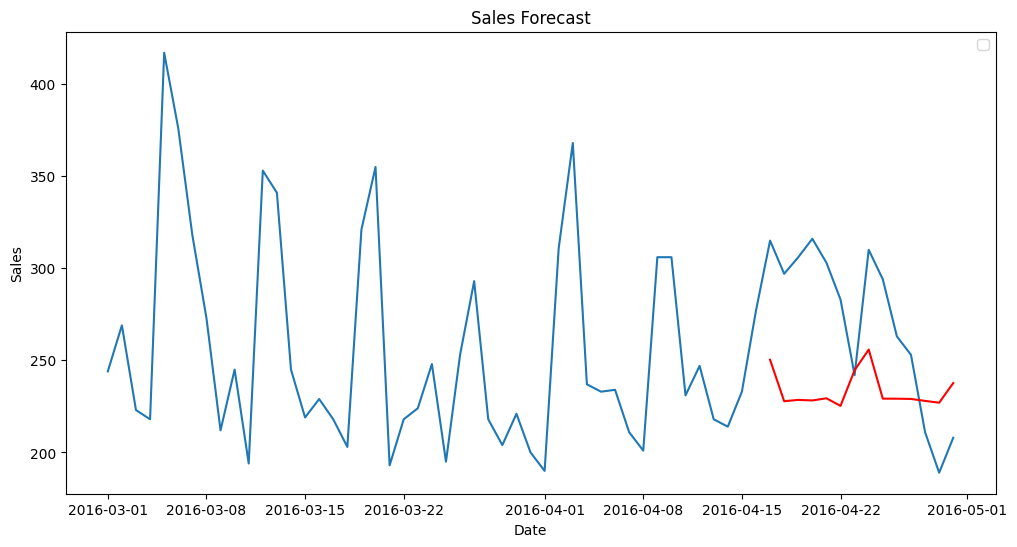

MAE: 49.600629096783464
MSE: 3063.17031249991
MAPE: 17.639083927637405


In [98]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

### Кластер 8

In [99]:
category_name = 'Крупная бытовая техника'
cluster = 8

daily_sales = df_clustering_1[(df_clustering_1['cluster'] == cluster) & (df_clustering_1['TN'] == f'{category_name}')][['OrderDate', 'Quant', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,117.0,20908.940171,1,1,0,1
2016-03-02,101.0,17117.514851,2,2,0,1
2016-03-03,97.0,20179.144330,3,3,0,1
2016-03-04,98.0,20093.653061,4,4,0,1
2016-03-05,140.0,20632.514286,5,5,1,1
2016-03-06,96.0,18927.562500,6,6,1,1
2016-03-07,119.0,19008.966387,0,7,0,1
2016-03-08,104.0,17081.201923,1,8,0,1
2016-03-09,88.0,19179.670455,2,9,0,1


In [100]:
params = [
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 20],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3, 7]
    }
]

for i, param in enumerate(params):
    print(f'Param set: {i}')
    
    data_features = lagged_features(daily_sales, 'OrderDate', param['cols'], param['lags'], param['agg'], param['windows'])

    train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
    train_df.fillna(-1000, inplace=True)
    test_df.fillna(-1000, inplace=True)
    X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
    y = train_df.Quant

    X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
    y_test = test_df.Quant

    categorical_features_indices = np.where(X.dtypes != float)[0]

    model = CatBoostRegressor(
        loss_function='MAPE',
        random_seed=42,
        logging_level='Silent'
    )

    model.fit(
        X, y,
        eval_set=(X_test, y_test),
        cat_features=categorical_features_indices,
        use_best_model=True,
        plot=True
    )

Param set: 0


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 1


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 2


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/2505788123.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [101]:
data_features = lagged_features(daily_sales, 'OrderDate', params[1]['cols'], params[1]['lags'], params[1]['agg'], params[1]['windows'])

train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y = train_df.Quant

X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    eval_set=(X_test, y_test),
    cat_features=categorical_features_indices,
    use_best_model=True,
    plot=True
)

X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3605975558.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3605975558.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,,
2016-03-01,117.0,20908.940171,1,1,0,1,-1.000000
2016-03-02,101.0,17117.514851,2,2,0,1,-1.000000
2016-03-03,97.0,20179.144330,3,3,0,1,-1.000000
2016-03-04,98.0,20093.653061,4,4,0,1,-1.000000
2016-03-05,140.0,20632.514286,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,139.0,20003.503597,1,26,0,0,103.577466
2016-04-27,110.0,19172.827273,2,27,0,0,109.848840
2016-04-28,105.0,20440.104762,3,28,0,0,105.212786


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


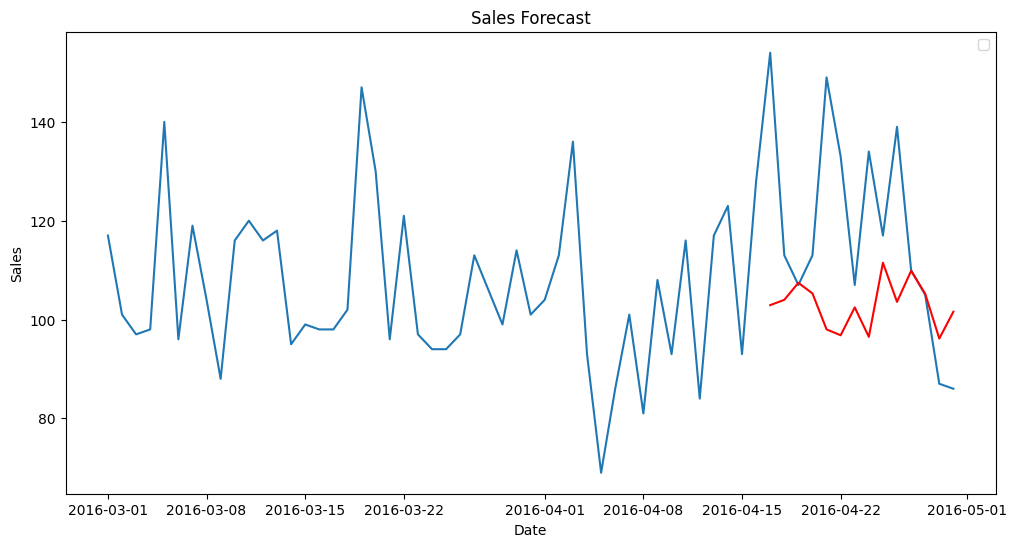

MAE: 18.820520043941087
MSE: 692.7756976965478
MAPE: 14.371834907436174


In [102]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

## Сделай сам

### Кластер 1

In [103]:
category_name = 'Сделай сам'
cluster = 1

daily_sales = df_clustering_1[(df_clustering_1['cluster'] == cluster) & (df_clustering_1['TN'] == f'{category_name}')][['OrderDate', 'Quant', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,147.0,6419.700680,1,1,0,0
2016-03-02,172.0,5353.924419,2,2,0,0
2016-03-03,185.0,5881.556757,3,3,0,0
2016-03-04,176.0,5563.244318,4,4,0,1
2016-03-05,157.0,4501.458599,5,5,1,1
2016-03-06,145.0,5944.696552,6,6,1,1
2016-03-07,130.0,5807.884615,0,7,0,1
2016-03-08,121.0,4878.347107,1,8,0,1
2016-03-09,177.0,5631.248588,2,9,0,0


In [108]:
params = [
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 20],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 20],
        'agg': ['mean', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 20],
        'agg': ['mean', 'percentile_90'],
        'windows': [1, 3]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 20],
        'agg': ['mean', 'sum'],
        'windows': [1, 3]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17],
        'agg': ['sum', 'percentile_50', 'percentile_10'],
        'windows': [1, 3]
    },
]

for i, param in enumerate(params):
    print(f'Param set: {i}')
    
    data_features = lagged_features(daily_sales, 'OrderDate', param['cols'], param['lags'], param['agg'], param['windows'])

    train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
    train_df.fillna(-1000, inplace=True)
    test_df.fillna(-1000, inplace=True)
    X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
    y = train_df.Quant

    X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
    y_test = test_df.Quant

    categorical_features_indices = np.where(X.dtypes != float)[0]

    model = CatBoostRegressor(
        loss_function='MAPE',
        random_seed=42,
        logging_level='Silent'
    )

    model.fit(
        X, y,
        eval_set=(X_test, y_test),
        cat_features=categorical_features_indices,
        use_best_model=True,
        plot=True
    )

Param set: 0


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 1


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


...

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 9


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [109]:
data_features = lagged_features(daily_sales, 'OrderDate', params[1]['cols'], params[1]['lags'], params[1]['agg'], params[1]['windows'])

train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y = train_df.Quant

X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    eval_set=(X_test, y_test),
    cat_features=categorical_features_indices,
    use_best_model=True,
    plot=True
)

X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3605975558.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3605975558.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,,
2016-03-01,147.0,6419.700680,1,1,0,0,-1.000000
2016-03-02,172.0,5353.924419,2,2,0,0,-1.000000
2016-03-03,185.0,5881.556757,3,3,0,0,-1.000000
2016-03-04,176.0,5563.244318,4,4,0,1,-1.000000
2016-03-05,157.0,4501.458599,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,324.0,6109.888889,1,26,0,1,165.093102
2016-04-27,242.0,6876.896694,2,27,0,1,164.378120
2016-04-28,222.0,6465.171171,3,28,0,1,167.322509


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


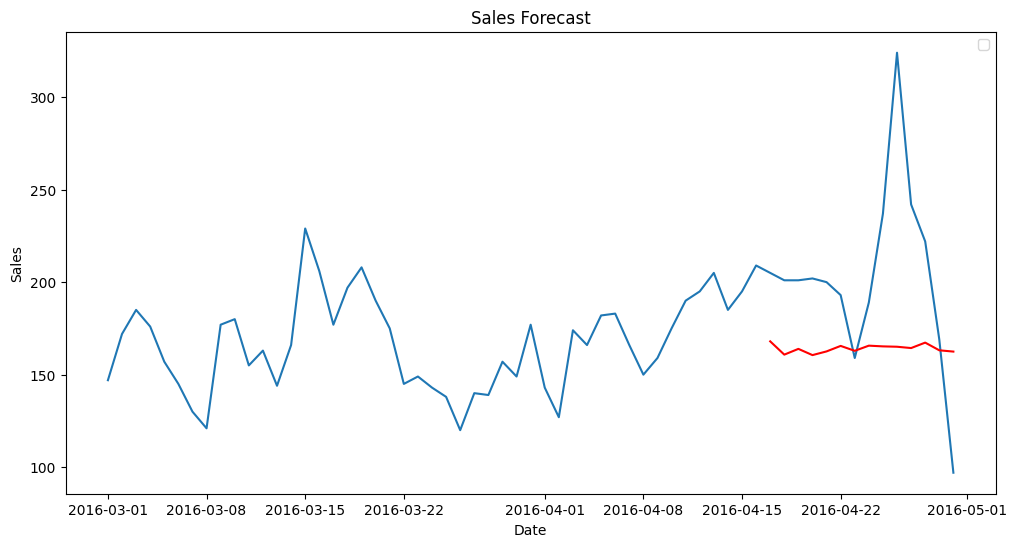

MAE: 48.71449085999353
MSE: 3751.256232099856
MAPE: 23.69109228087225


In [110]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')

### Кластер 8

In [111]:
category_name = 'Сделай сам'
cluster = 8

daily_sales = df_clustering_1[(df_clustering_1['cluster'] == cluster) & (df_clustering_1['TN'] == f'{category_name}')][['OrderDate', 'Quant', 'RowSum']]\
    .groupby('OrderDate').sum()\
    .resample('D').sum()
daily_sales['RowSum'] /= daily_sales['Quant']
action = df[df['TN'] == category_name][['Quant_action', 'OrderDate']].groupby(['OrderDate']).sum()
action['IsAction'] = (action['Quant_action'] > 10).apply(lambda x: int(x))

data = daily_sales.reset_index().copy(deep = True)

daily_sales["weekday"] = daily_sales.index.weekday
daily_sales["monthday"] = daily_sales.index.day
daily_sales['is_weekend'] = daily_sales.index.weekday.isin([5,6])*1

daily_sales = daily_sales.join(action[['IsAction']], on='OrderDate')

daily_sales.head(10)

,Quant,RowSum,weekday,monthday,is_weekend,IsAction
OrderDate,,,,,,
2016-03-01,66.0,7584.181818,1,1,0,0
2016-03-02,43.0,8753.023256,2,2,0,0
2016-03-03,51.0,9339.333333,3,3,0,0
2016-03-04,56.0,6400.660714,4,4,0,1
2016-03-05,38.0,9091.578947,5,5,1,1
2016-03-06,42.0,5573.380952,6,6,1,1
2016-03-07,39.0,10582.230769,0,7,0,1
2016-03-08,35.0,7781.171429,1,8,0,1
2016-03-09,94.0,4578.031915,2,9,0,0


In [112]:
params = [
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 20],
        'agg': ['sum', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 20],
        'agg': ['mean', 'percentile_90'],
        'windows': [1, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 20],
        'agg': ['mean', 'percentile_90'],
        'windows': [1, 3]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 20],
        'agg': ['mean', 'sum'],
        'windows': [1, 3]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3, 7]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17, 20],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17],
        'agg': ['sum', 'percentile_90', 'percentile_10'],
        'windows': [1, 3]
    },
    {
        'cols': ['Quant', 'RowSum'],
        'lags': [14, 17],
        'agg': ['sum', 'percentile_50', 'percentile_10'],
        'windows': [1, 3]
    },
]

for i, param in enumerate(params):
    print(f'Param set: {i}')
    
    data_features = lagged_features(daily_sales, 'OrderDate', param['cols'], param['lags'], param['agg'], param['windows'])

    train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
    train_df.fillna(-1000, inplace=True)
    test_df.fillna(-1000, inplace=True)
    X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
    y = train_df.Quant

    X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
    y_test = test_df.Quant

    categorical_features_indices = np.where(X.dtypes != float)[0]

    model = CatBoostRegressor(
        loss_function='MAPE',
        random_seed=42,
        logging_level='Silent'
    )

    model.fit(
        X, y,
        eval_set=(X_test, y_test),
        cat_features=categorical_features_indices,
        use_best_model=True,
        plot=True
    )

Param set: 0


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 1


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


...

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Param set: 9


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:70: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/4106359441.py:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

In [113]:
data_features = lagged_features(daily_sales, 'OrderDate', params[4]['cols'], params[4]['lags'], params[4]['agg'], params[4]['windows'])

train_df, test_df = data_features.iloc[:-14], data_features.iloc[-14:]
train_df.fillna(-1000, inplace=True)
test_df.fillna(-1000, inplace=True)
X = train_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y = train_df.Quant

X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant

categorical_features_indices = np.where(X.dtypes != float)[0]

model = CatBoostRegressor(
    loss_function='MAPE',
    random_seed=42,
    logging_level='Silent'
)

model.fit(
    X, y,
    eval_set=(X_test, y_test),
    cat_features=categorical_features_indices,
    use_best_model=True,
    plot=True
)

X_test = test_df.drop(['Quant', 'RowSum', 'OrderDate'], axis=1)
y_test = test_df.Quant
predictions = model.predict(X_test)
daily_sales['Predictions'] = [-1] * (len(daily_sales) - 14) + list(predictions)
daily_sales

/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3055619365.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.fillna(-1000, inplace=True)
/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/3055619365.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.fillna(-1000, inplace=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

,Quant,RowSum,weekday,monthday,is_weekend,IsAction,Predictions
OrderDate,,,,,,,
2016-03-01,66.0,7584.181818,1,1,0,0,-1.000000
2016-03-02,43.0,8753.023256,2,2,0,0,-1.000000
2016-03-03,51.0,9339.333333,3,3,0,0,-1.000000
2016-03-04,56.0,6400.660714,4,4,0,1,-1.000000
2016-03-05,38.0,9091.578947,5,5,1,1,-1.000000
...,...,...,...,...,...,...,...
2016-04-26,105.0,9804.104762,1,26,0,1,66.677115
2016-04-27,108.0,8480.740741,2,27,0,1,70.514509
2016-04-28,108.0,9786.120370,3,28,0,1,67.768448


/var/folders/bh/d932d5zj56z9_y_7lh3s66ndf1n4c9/T/ipykernel_73934/1450528397.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


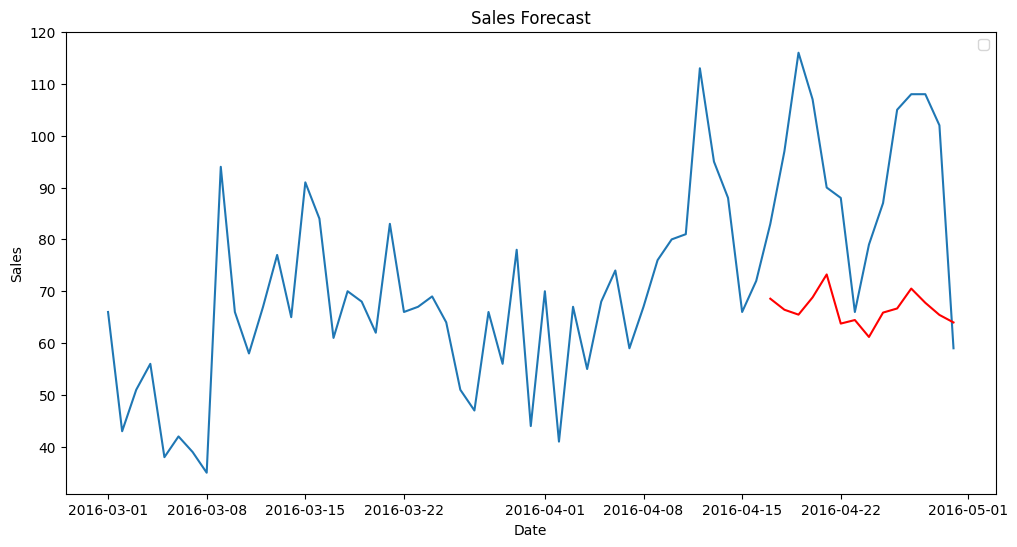

MAE: 26.627017313365837
MSE: 902.9065386183494
MAPE: 26.874309385149616


In [114]:
forecast_periods = 14
forecast = predictions

plt.figure(figsize=(12, 6))
plt.plot(daily_sales.index, daily_sales.Quant)
plt.plot(daily_sales.index[-14:], daily_sales.Predictions[-14:], color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

observed = daily_sales[-14:]
mae = mean_absolute_error(daily_sales['Quant'][-14:], predictions)
mse = mean_squared_error(daily_sales['Quant'][-14:], predictions)
mape = mean_absolute_percentage_error(daily_sales['Quant'][-14:], predictions) * 100.0
print(f'MAE: {mae}')
print(f'MSE: {mse}')
print(f'MAPE: {mape}')